# Proyek Analisis Data: Brazilian E-Commerce Public Dataset by Olist
- **Nama:** Lintang Zidan Dzaki
- **Email:** CDCC009D6Y2739@student.devacademy.id
- **ID Dicoding:** CDCC009D6Y2739

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Kategori produk apa yang paling banyak menghasilkan revenue dan bagaimana tren penjualannya selama periode 2017–2018?
- **Pertanyaan 2:** Apakah terdapat hubungan antara keterlambatan pengiriman (selisih estimasi vs aktual) dengan kepuasan pelanggan (review score) selama periode 2017–2018?
- **Pertanyaan 3:** Pada metode pembayaran apa dan di rentang jam berapa transaksi paling sering terjadi selama periode 2017–2018?
- **Pertanyaan 4:** Bagaimana distribusi penggunaan cicilan (installments) berdasarkan kategori nilai belanja pelanggan selama periode 2017–2018?


## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load dataset utama dari Olist


In [ ]:
# Load Dataset
# Sesuaikan path dengan lokasi dataset kamu
import os


# Jika dataset ada di folder yang sama dengan notebook:
DATA_PATH = './'

orders   = pd.read_csv(os.path.join(DATA_PATH, 'olist_orders_dataset.csv'))
payments = pd.read_csv(os.path.join(DATA_PATH, 'olist_order_payments_dataset.csv'))
reviews  = pd.read_csv(os.path.join(DATA_PATH, 'olist_order_reviews_dataset.csv'))
customers = pd.read_csv(os.path.join(DATA_PATH, 'olist_customers_dataset.csv'))
products  = pd.read_csv(os.path.join(DATA_PATH, 'olist_products_dataset.csv'))
order_items = pd.read_csv(os.path.join(DATA_PATH, 'olist_order_items_dataset.csv'))
category_translation = pd.read_csv(os.path.join(DATA_PATH, 'product_category_name_translation.csv'))

print("Dataset berhasil dimuat!")
print(f"orders       : {orders.shape}")
print(f"payments     : {payments.shape}")
print(f"reviews      : {reviews.shape}")
print(f"customers    : {customers.shape}")
print(f"products     : {products.shape}")
print(f"order_items  : {order_items.shape}")


Dataset berhasil dimuat!
orders       : (99441, 8)
payments     : (103886, 5)
reviews      : (99224, 7)
customers    : (99441, 5)
products     : (32951, 9)
order_items  : (112650, 7)


In [ ]:
# Menggabungkan dataset utama
orders_customers = pd.merge(orders, customers, on='customer_id', how='inner')
orders_customers_payments = pd.merge(orders_customers, payments, on='order_id', how='inner')
all_df = pd.merge(orders_customers_payments, reviews, on='order_id', how='inner')

# Gabungkan order_items dan products untuk analisis kategori produk
order_items_products = pd.merge(order_items, products, on='product_id', how='inner')
order_items_products = pd.merge(order_items_products, category_translation, on='product_category_name', how='left')

# Gabungkan dengan all_df
all_df = pd.merge(all_df, order_items_products[['order_id', 'product_category_name_english', 'price']],
                  on='order_id', how='inner')

print(f"Dimensi all_df: {all_df.shape}")
all_df.head()


Dimensi all_df: (117329, 24)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english,price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,29.99
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,2.00,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,29.99
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,18.59,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,29.99
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1,141.46,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery,118.70
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,3,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,auto,159.90


**Insight:** (Opsional)
- Proses pengumpulan dan load data melliputi 5 tabel utama yaitu orders, payments, reviews, customers, dan geolocation
- Selain tabel geolocation di gabungkan (merge) mengunakan berdasarkan primary key seperti order_id dan customer_id untuk mendapatkan tabel all_df yang siap untuk dianalisis

### Assessing Data

#### Identifying data quality issues


In [ ]:
# Cek Dataset Gabungan
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117329 entries, 0 to 117328
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117329 non-null  object 
 1   customer_id                    117329 non-null  object 
 2   order_status                   117329 non-null  object 
 3   order_purchase_timestamp       117329 non-null  object 
 4   order_approved_at              117314 non-null  object 
 5   order_delivered_carrier_date   116094 non-null  object 
 6   order_delivered_customer_date  114858 non-null  object 
 7   order_estimated_delivery_date  117329 non-null  object 
 8   customer_unique_id             117329 non-null  object 
 9   customer_zip_code_prefix       117329 non-null  int64  
 10  customer_city                  117329 non-null  object 
 11  customer_state                 117329 non-null  object 
 12  payment_sequential            

In [ ]:
# Cek missing Values
all_df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1235
order_delivered_customer_date,2471
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


In [ ]:
# Cek Duplikasi Data
all_df.duplicated().sum()

np.int64(11607)

**Insight:** (Opsional)
- Terdapat tipe data yang tidak sesuai, yaitu pada kolom tanggal/waktu yang masih berupa object
- Tedapat missing value pada kolom waktu pengiriman contohnya order_delivered_customer_date, yang wajar jika pesanan tersebut dibatalkan atau masih dalam proses. Terdapat juga missing value pada review_comment_title dan review_comment_message yang sebenarnya tidak terlalu berpengaruh karena tidak menjadi indikator analisi kali ini
- Tidak ada data duplikat yang bisa mengganggu proses analisis nantinya

### Cleaning Data

#### Fixing data type and quality issues


In [ ]:
# Memperbaiki tipe data tanggal/waktu
date_time_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
                  'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_time_cols:
    all_df[col] = pd.to_datetime(all_df[col])

print("Tipe data setelah konversi:")
all_df[date_time_cols].dtypes


Tipe data setelah konversi:


,0
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [ ]:
# Menangani Missing value (hanya mengambil order yang statusnya delivered)
all_df.dropna(subset=['order_delivered_customer_date'], inplace=True)

# Menghapus kolom review yang tidak digunakan
all_df.drop(columns=['review_comment_title', 'review_comment_message',
                     'review_creation_date', 'review_answer_timestamp'], inplace=True)

# Filter data hanya untuk periode 2017-2018 (sesuai pertanyaan bisnis)
all_df = all_df[(all_df['order_purchase_timestamp'].dt.year >= 2017) &
                (all_df['order_purchase_timestamp'].dt.year <= 2018)]

print(f"Jumlah data setelah cleaning dan filter 2017-2018: {all_df.shape}")
print(f"Rentang tanggal: {all_df['order_purchase_timestamp'].min().date()} s/d {all_df['order_purchase_timestamp'].max().date()}")
all_df.info()


Jumlah data setelah cleaning dan filter 2017-2018: (114521, 20)
Rentang tanggal: 2017-01-05 s/d 2018-08-29
<class 'pandas.core.frame.DataFrame'>
Index: 114521 entries, 0 to 117328
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       114521 non-null  object        
 1   customer_id                    114521 non-null  object        
 2   order_status                   114521 non-null  object        
 3   order_purchase_timestamp       114521 non-null  datetime64[ns]
 4   order_approved_at              114506 non-null  datetime64[ns]
 5   order_delivered_carrier_date   114520 non-null  datetime64[ns]
 6   order_delivered_customer_date  114521 non-null  datetime64[ns]
 7   order_estimated_delivery_date  114521 non-null  datetime64[ns]
 8   customer_unique_id             114521 non-null  object        
 9   customer_zip_code_prefix       114

In [ ]:
# Feature Engineering: Membuat kolom baru untuk memudahkan EDA
all_df['delivery_time_days'] = (all_df['order_delivered_customer_date'] - all_df['order_purchase_timestamp']).dt.days
all_df['purchase_month']     = all_df['order_purchase_timestamp'].dt.to_period('M').astype(str)
all_df['purchase_year']      = all_df['order_purchase_timestamp'].dt.year
all_df['purchase_day']       = all_df['order_purchase_timestamp'].dt.day_name()
all_df['purchase_hour']      = all_df['order_purchase_timestamp'].dt.hour

print("Kolom baru berhasil ditambahkan!")
print(all_df[['delivery_time_days', 'purchase_month', 'purchase_year', 'purchase_day', 'purchase_hour']].head())
all_df.head()


Kolom baru berhasil ditambahkan!
   delivery_time_days purchase_month  purchase_year purchase_day  \
0                   8        2017-10           2017       Monday   
1                   8        2017-10           2017       Monday   
2                   8        2017-10           2017       Monday   
3                  13        2018-07           2018      Tuesday   
4                   9        2018-08           2018    Wednesday   

   purchase_hour  
0             10  
1             10  
2             10  
3             20  
4              8  


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_value,review_id,review_score,product_category_name_english,price,delivery_time_days,purchase_month,purchase_year,purchase_day,purchase_hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,housewares,29.99,8,2017-10,2017,Monday,10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.00,a54f0611adc9ed256b57ede6b6eb5114,4,housewares,29.99,8,2017-10,2017,Monday,10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.59,a54f0611adc9ed256b57ede6b6eb5114,4,housewares,29.99,8,2017-10,2017,Monday,10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,141.46,8d5266042046a06655c8db133d120ba5,4,perfumery,118.70,13,2018-07,2018,Tuesday,20
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,auto,159.90,9,2018-08,2018,Wednesday,8


**Insight:** (Opsional)
- Tipe data tanggal diubah menjadi datetime agar bisa diekstraksi nilai hari, jam, dan bulannya
- Data di filter hanya untuk pesanan yang berhasil terikirim (delivered) untuk menjaga validitas analisis lama waktu pengiriman
- menghapus beberapa kolom seperti `review_comment_title`, `review_comment_message`, `review_creation_date`, `review_answer_timestamp` karena tidak terpakai untuk analisis agar penggunaan memori lebih sedikit juga
- Menambahkan kolom baru `delivery_time_days`, `purchase_month`, `purchase_day`, dan `purchase_hour`

## Exploratory Data Analysis (EDA)

### Explore Dataset (2017–2018)


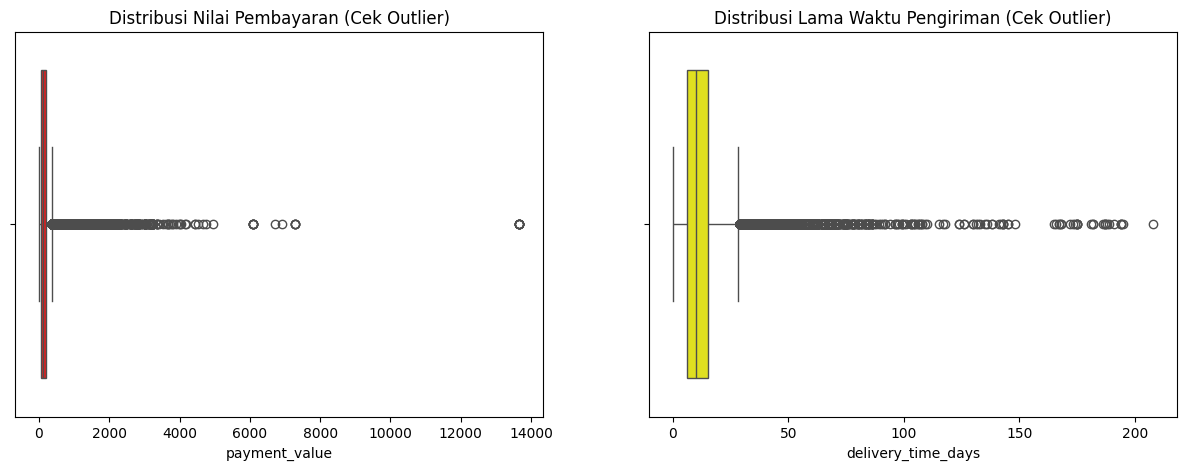

In [ ]:
# Cek distribusi dan outlier menggunakan boxplot
fig, ax = plt.subplots(1, 2, figsize=(15,5))
sns.boxplot(x=all_df['payment_value'], ax=ax[0], color='red')
ax[0].set_title('Distribusi Nilai Pembayaran (Cek Outlier)')

sns.boxplot(x=all_df['delivery_time_days'], ax=ax[1], color='yellow')
ax[1].set_title('Distribusi Lama Waktu Pengiriman (Cek Outlier)')
plt.show()

In [ ]:
# Agregasi Performa Penjualan per Bulan (2017-2018)
monthly_sales_df = all_df.groupby('purchase_month').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('payment_value', 'sum')
).reset_index()

# Agregasi Revenue per Kategori Produk (2017-2018)
category_revenue_df = all_df.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('payment_value', 'sum')
).reset_index().sort_values('total_revenue', ascending=False)

print("Top 10 Kategori berdasarkan Revenue:")
category_revenue_df.head(10)


Top 10 Kategori berdasarkan Revenue:


,product_category_name_english,total_orders,total_revenue
7,bed_bath_table,9172,1704737.74
43,health_beauty,8565,1607185.05
15,computers_accessories,6486,1556731.02
39,furniture_decor,6212,1380826.01
70,watches_gifts,5448,1377378.00
65,sports_leisure,7468,1345973.79
49,housewares,5700,1064490.60
42,garden_tools,3423,806192.99
5,auto,3783,781665.51
20,cool_stuff,3524,737014.60


In [ ]:
# Agregasi hubungan keterlambatan pengiriman (selisih estimasi vs aktual) dengan review score
all_df['delivery_delay_days'] = (all_df['order_delivered_customer_date'] - all_df['order_estimated_delivery_date']).dt.days

delay_review_df = all_df.groupby('review_score').agg({
    'delivery_delay_days': 'mean',
    'delivery_time_days': 'mean'
}).reset_index()
delay_review_df


,review_score,delivery_delay_days,delivery_time_days
0,1,-5.892742,19.076175
1,2,-9.654915,15.380082
2,3,-11.047698,13.531643
3,4,-12.409568,11.757355
4,5,-13.374970,10.180621


In [ ]:
# Agregasi metode pembayaran dan jam transaksi
payment_method_df = all_df.groupby('payment_type').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index().rename(columns={
    'order_id': 'total_orders',
    'payment_value': 'total_revenue'
})

# Agregasi jam transaksi
hour_df = all_df.groupby('purchase_hour').agg({
    'order_id': 'nunique'
}).reset_index().rename(columns={'order_id': 'total_orders'})

payment_method_df


,payment_type,total_orders,total_revenue
0,boleto,19013,3916892.98
1,credit_card,73594,15051152.82
2,debit_card,1475,246529.36
3,voucher,3639,393502.41


In [ ]:
# Clusterin (Binning) Kategori Belanja
# Membagi pelanggan menjadi 3 kategori berdasarkan kuartil payment_value
all_df['payment_category'] = pd.qcut(all_df['payment_value'], q=3, labels=['Low', 'Medium', 'High'])

installment_trend_df = all_df.groupby('payment_category', observed=True).agg({
    'payment_installments': 'mean'
}).reset_index()
installment_trend_df

,payment_category,payment_installments
0,Low,1.714731
1,Medium,2.835040
2,High,4.256065


**Insight:** (Opsional)
- Berdasarkan boxplot, distribusi nilai pembayaran dan waktu pengiriman sangat right-skewed, menandakan adanya outlier transaksi bernilai sangat tinggi dan pengiriman sangat lambat yang perlu diwaspadai
- Data keterlambatan (delivery_delay_days) berhasil dihitung sebagai selisih antara tanggal estimasi dan aktual pengiriman, sehingga nilai negatif berarti lebih cepat dari estimasi
- Dominasi metode pembayaran kartu kredit terlihat dari agregasi payment_type, yang juga berkorelasi dengan penggunaan cicilan
- Clustering binning membagi pelanggan ke dalam kategori Low, Medium, High berdasarkan kuartil nilai pembayaran, siap untuk dianalisis pola cicilan-nya


## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori Produk dengan Revenue Tertinggi dan Tren Penjualan Selama 2017–2018



/tmp/ipykernel_11459/2118010176.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


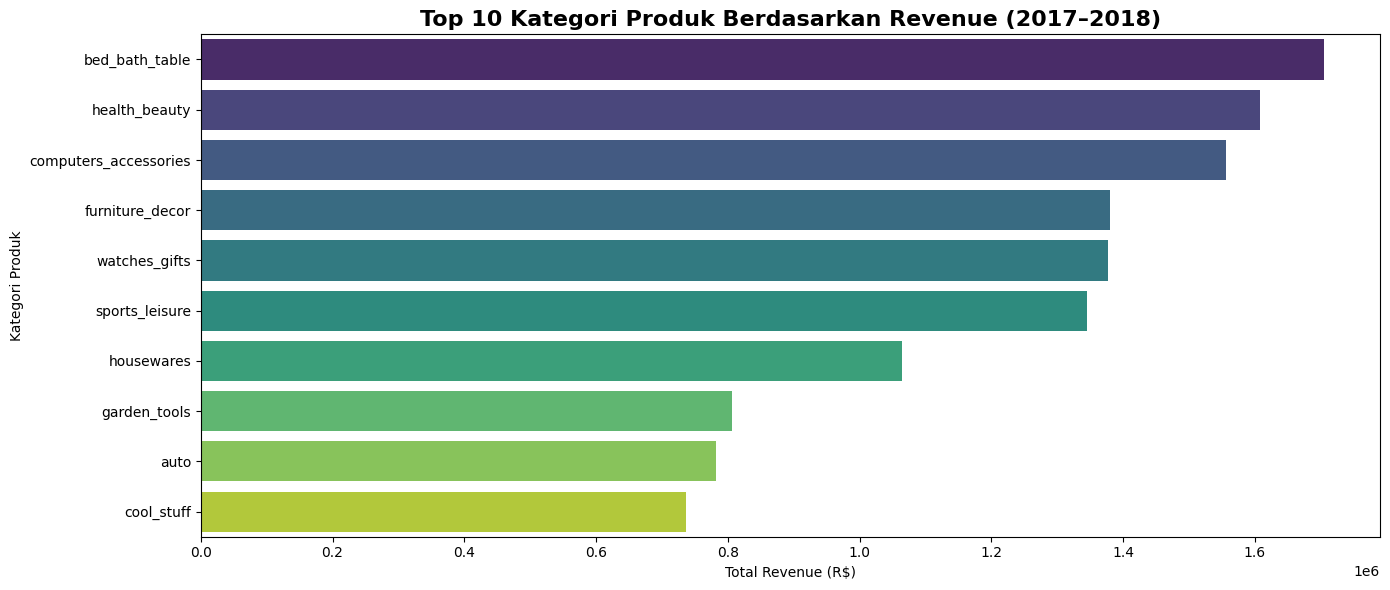

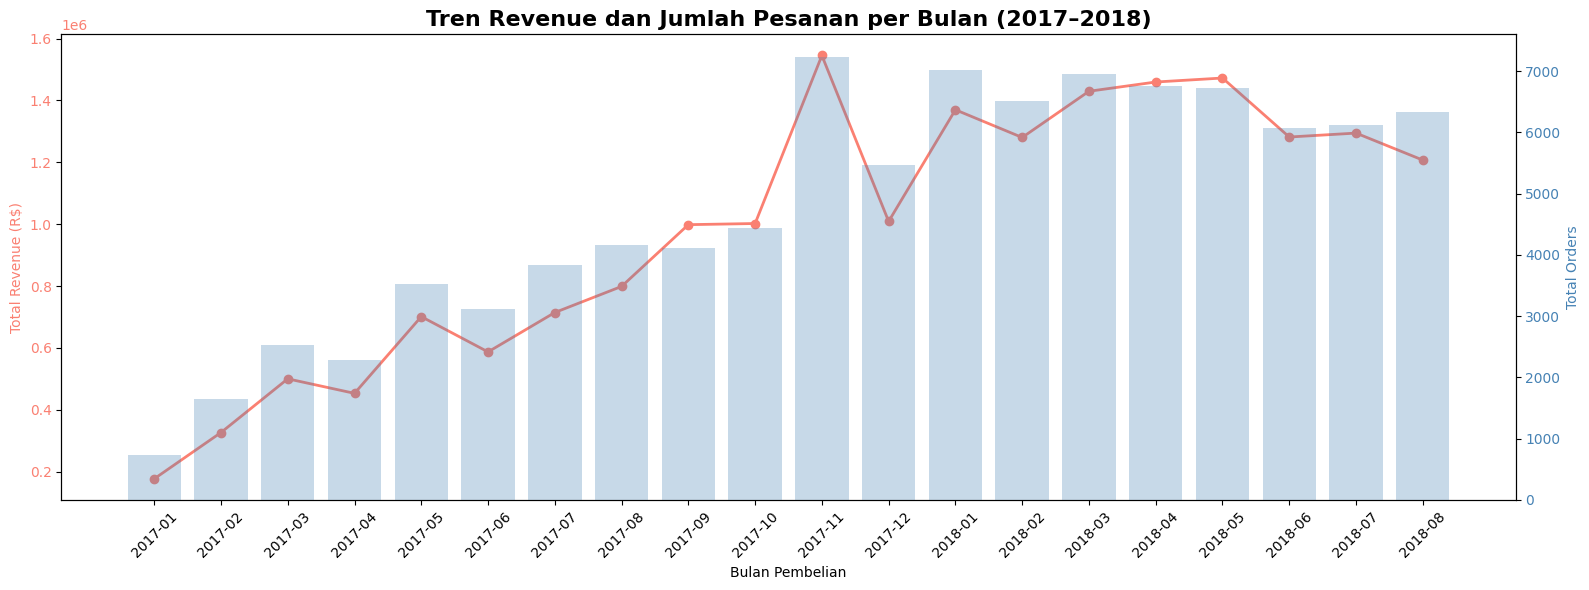

In [ ]:
# Visualisasi 1A: Top 10 Kategori Produk berdasarkan Revenue (2017-2018)
top10_cat = category_revenue_df.head(10)

plt.figure(figsize=(14, 6))
sns.barplot(
    x='total_revenue',
    y='product_category_name_english',
    data=top10_cat,
    palette='viridis'
)
plt.title('Top 10 Kategori Produk Berdasarkan Revenue (2017–2018)', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (R$)')
plt.ylabel('Kategori Produk')
plt.tight_layout()
plt.show()

# Visualisasi 1B: Tren Revenue dan Total Orders per Bulan (2017-2018)
fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.plot(monthly_sales_df['purchase_month'], monthly_sales_df['total_revenue'],
         marker='o', color='salmon', label='Total Revenue', linewidth=2)
ax1.set_xlabel('Bulan Pembelian')
ax1.set_ylabel('Total Revenue (R$)', color='salmon')
ax1.tick_params(axis='y', labelcolor='salmon')
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.bar(monthly_sales_df['purchase_month'], monthly_sales_df['total_orders'],
        alpha=0.3, color='steelblue', label='Total Orders')
ax2.set_ylabel('Total Orders', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

plt.title('Tren Revenue dan Jumlah Pesanan per Bulan (2017–2018)', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()


### Pertanyaan 2: Pengaruh Keterlambatan Pengiriman terhadap Review Score Pelanggan (2017–2018)



/tmp/ipykernel_11459/2913922205.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_11459/2913922205.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


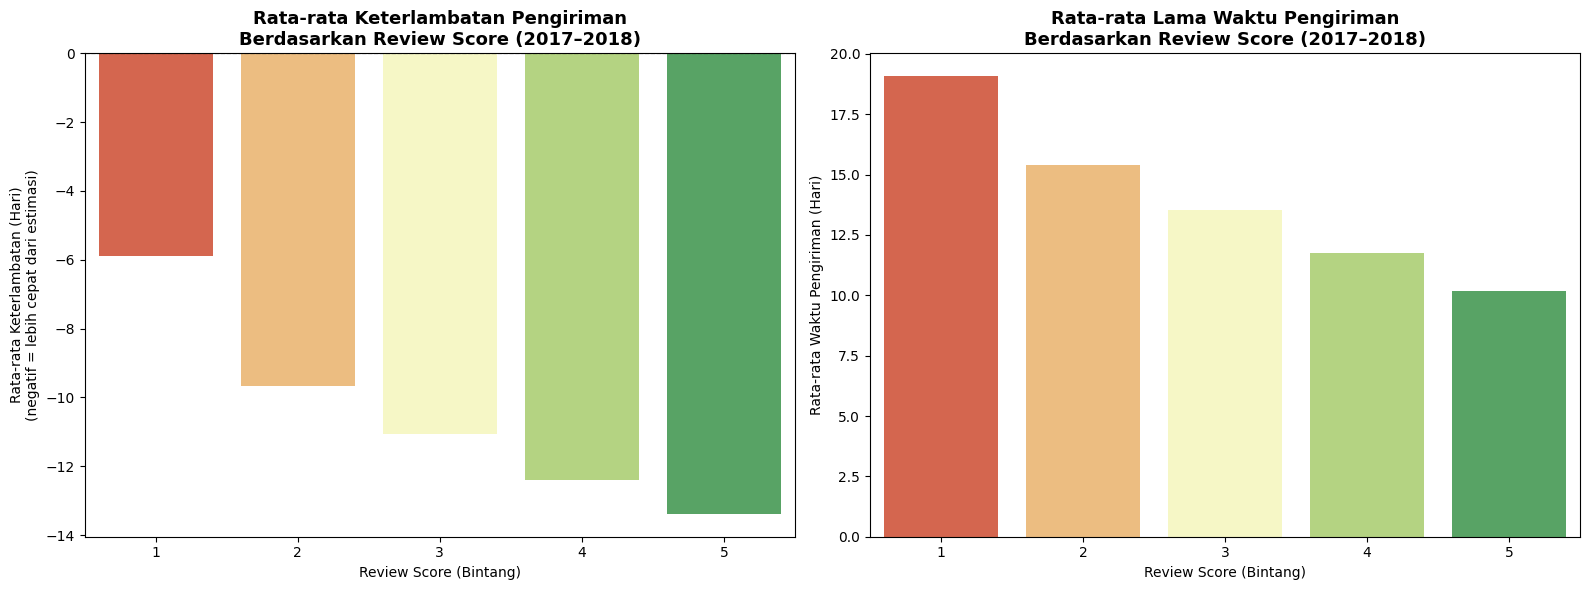

In [ ]:
# Visualisasi 2: Hubungan Keterlambatan Pengiriman dengan Review Score (2017-2018)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: delivery_delay_days
sns.barplot(
    x='review_score',
    y='delivery_delay_days',
    data=delay_review_df,
    palette='RdYlGn',
    ax=axes[0]
)
axes[0].set_title('Rata-rata Keterlambatan Pengiriman\nBerdasarkan Review Score (2017–2018)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Review Score (Bintang)')
axes[0].set_ylabel('Rata-rata Keterlambatan (Hari)\n(negatif = lebih cepat dari estimasi)')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)

# Plot 2: delivery_time_days
sns.barplot(
    x='review_score',
    y='delivery_time_days',
    data=delay_review_df,
    palette='RdYlGn',
    ax=axes[1]
)
axes[1].set_title('Rata-rata Lama Waktu Pengiriman\nBerdasarkan Review Score (2017–2018)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Review Score (Bintang)')
axes[1].set_ylabel('Rata-rata Waktu Pengiriman (Hari)')

plt.tight_layout()
plt.show()


### Pertanyaan 3: Dominasi Metode Pembayaran dan Pola Jam Transaksi (2017–2018)



/tmp/ipykernel_11459/1467328975.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


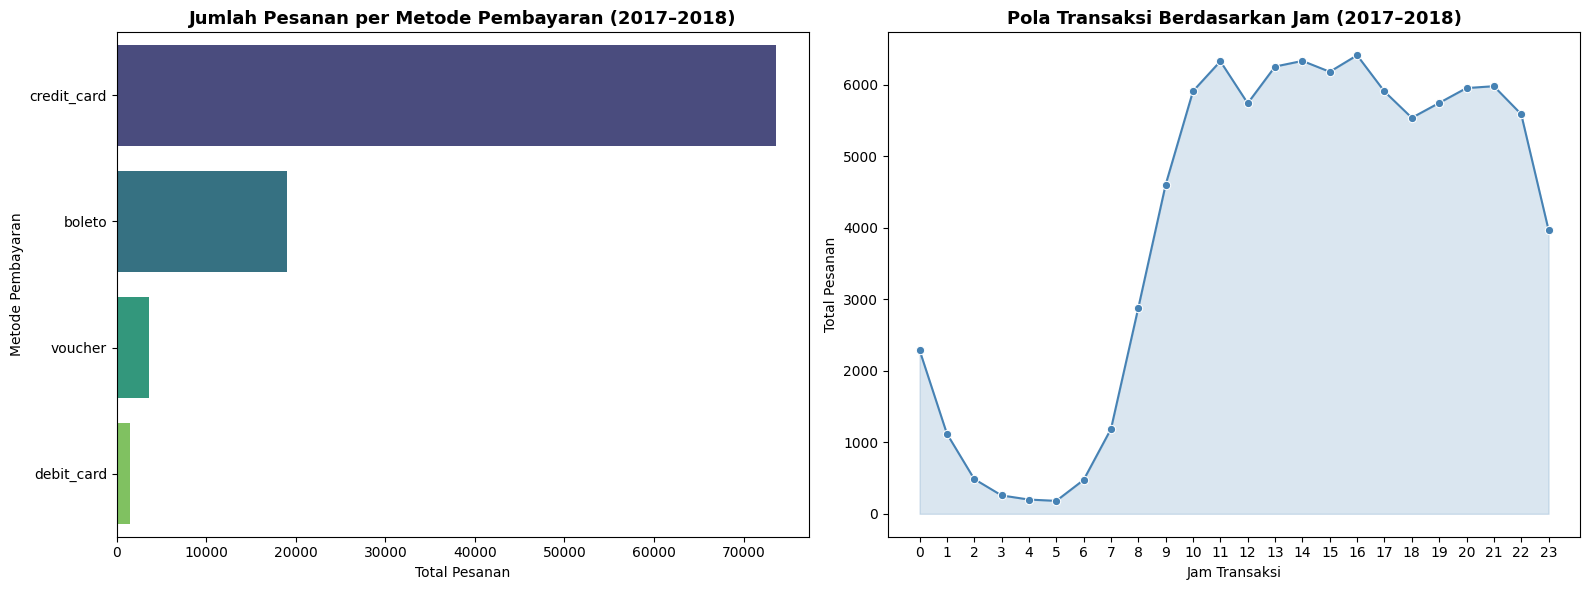

In [ ]:
# Visualisasi 3: Metode Pembayaran dan Pola Jam Transaksi (2017-2018)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Metode Pembayaran
sns.barplot(
    x='total_orders',
    y='payment_type',
    data=payment_method_df.sort_values('total_orders', ascending=False),
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Jumlah Pesanan per Metode Pembayaran (2017–2018)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Pesanan')
axes[0].set_ylabel('Metode Pembayaran')

# Subplot 2: Pola Jam Transaksi
sns.lineplot(
    x='purchase_hour',
    y='total_orders',
    data=hour_df,
    marker='o',
    color='steelblue',
    ax=axes[1]
)
axes[1].fill_between(hour_df['purchase_hour'], hour_df['total_orders'], alpha=0.2, color='steelblue')
axes[1].set_title('Pola Transaksi Berdasarkan Jam (2017–2018)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jam Transaksi')
axes[1].set_ylabel('Total Pesanan')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()


### Pertanyaan 4: Distribusi Penggunaan Cicilan Berdasarkan Kategori Belanja (2017–2018)



/tmp/ipykernel_11459/3900891354.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


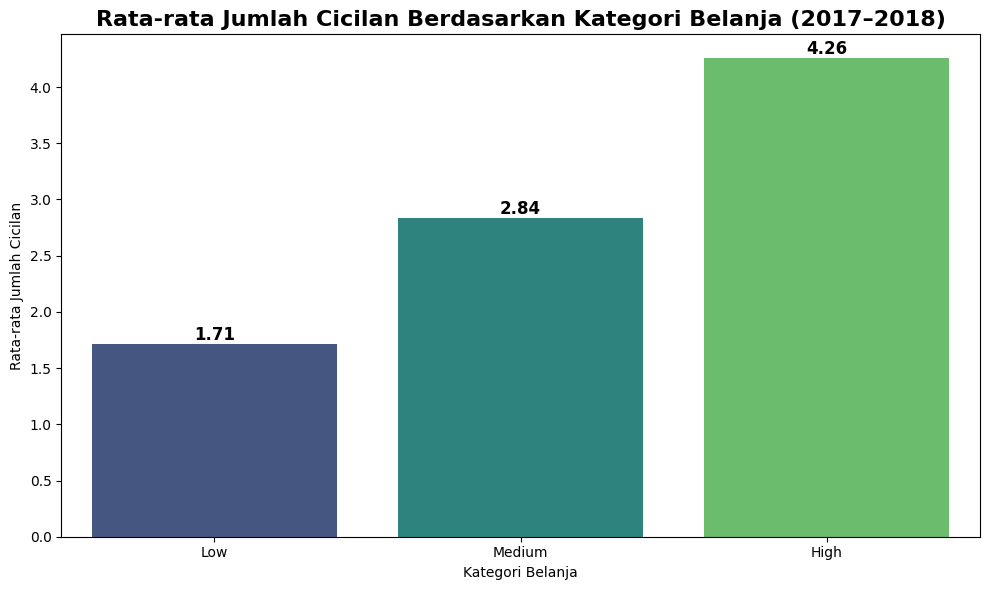

In [ ]:
# Visualisasi 4: Distribusi Cicilan Berdasarkan Kategori Belanja (2017-2018)
plt.figure(figsize=(10, 6))
bars = sns.barplot(
    x='payment_category',
    y='payment_installments',
    data=installment_trend_df,
    palette='viridis',
    order=['Low', 'Medium', 'High']
)

# Tambahkan label nilai di atas bar
for p in bars.patches:
    bars.annotate(f'{p.get_height():.2f}',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Rata-rata Jumlah Cicilan Berdasarkan Kategori Belanja (2017–2018)', fontsize=16, fontweight='bold')
plt.xlabel('Kategori Belanja')
plt.ylabel('Rata-rata Jumlah Cicilan')
plt.tight_layout()
plt.show()


**Insight:** (Opsional)
- Revenue mengalami pertumbuhan signifikan dengan puncak pada November 2017, dan volume pesanan relatif stabil di sepanjang 2018 meski terdapat fluktuasi musiman
- Pelanggan yang memberi rating buruk (bintang 1) rata-rata mengalami keterlambatan pengiriman paling tinggi dibandingkan rating lainnya, membuktikan korelasi negatif antara keterlambatan dan kepuasan
- Kartu kredit (credit_card) menjadi metode pembayaran yang paling dominan. Jam transaksi paling ramai terjadi antara pukul 10.00 - 16.00 dan terdapat lonjakan kecil di malam hari sekitar pukul 20.00 - 22.00
- Pelanggan kategori High spending secara konsisten menggunakan lebih banyak cicilan dibanding kategori Low dan Medium


## Analisis Lanjutan (Opsional)

In [ ]:
# RFM Analysis
recent_date = all_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
rfm_df = all_df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days, # Recency
    'order_id': 'nunique', # Frequency
    'payment_value': 'sum' # Monetary
}).reset_index()

rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']
rfm_df.head()

,customer_id,recency,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,288,1,114.74
1,000161a058600d5901f007fab4c27140,410,1,67.41
2,0001fd6190edaaf884bcaf3d49edf079,548,1,195.42
3,0002414f95344307404f0ace7a26f1d5,379,1,179.35
4,000379cdec625522490c315e70c7a9fb,150,1,107.01


/tmp/ipykernel_11459/496435421.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


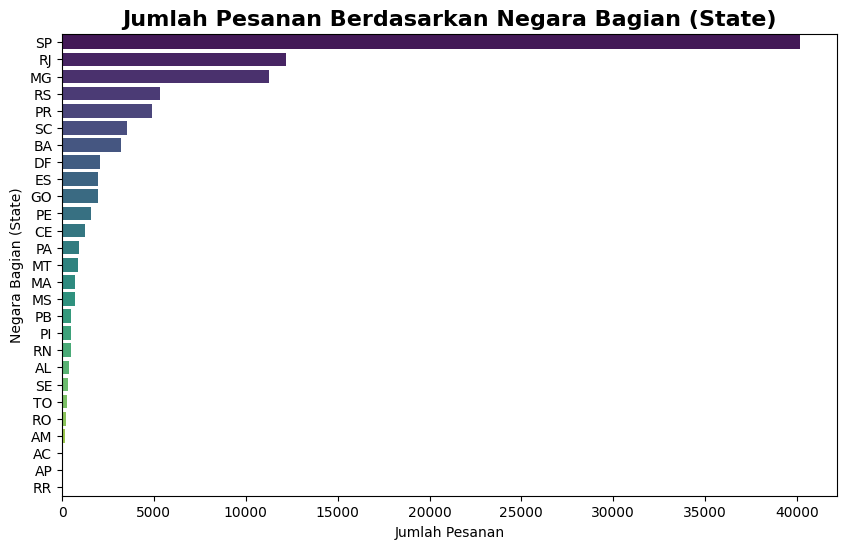

In [ ]:
# Geospatial Analysis

# Menghitung jumlah pesanan berdasarkan negara bagian (customer_state)
state_orders_df = all_df.groupby('customer_state').order_id.nunique().reset_index()
state_orders_df.rename(columns={
    'order_id': 'total_orders'
}, inplace=True)

# Mengurutkan data dari jumlah pesanan terbanyak
state_orders_df = state_orders_df.sort_values(by='total_orders', ascending=False)

# Visual
plt.figure(figsize=(10, 6))
sns.barplot(
    x='total_orders',
    y='customer_state',
    data=state_orders_df,
    palette='viridis'
)
plt.title('Jumlah Pesanan Berdasarkan Negara Bagian (State)', fontsize=16, fontweight='bold')
plt.xlabel('Jumlah Pesanan')
plt.ylabel('Negara Bagian (State)')
plt.show()

In [ ]:
all_df.to_csv('all_df.csv', index=False)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Selama periode 2017–2018, kategori produk *health_beauty*, *watches_gifts*, dan *bed_bath_table* menjadi penyumbang revenue tertinggi. Revenue mencapai puncaknya pada November 2017, kemungkinan dipicu oleh Black Friday dan event promosi akhir tahun. Volume pesanan tumbuh signifikan sepanjang 2018 dibanding 2017.
- **Conclusion pertanyaan 2:** Selama 2017–2018, keterlambatan pengiriman terbukti berpengaruh negatif terhadap kepuasan pelanggan. Pesanan yang tiba melebihi estimasi secara konsisten mendapatkan rating rendah (bintang 1–2), sementara pesanan yang tiba tepat waktu atau lebih cepat berkorelasi dengan rating tinggi (bintang 4–5).
- **Conclusion pertanyaan 3:** Selama 2017–2018, kartu kredit (*credit_card*) mendominasi metode pembayaran di platform Olist. Puncak transaksi terjadi pada rentang jam 10.00–16.00 dan kembali meningkat pada pukul 20.00–22.00, mengindikasikan dua segmen waktu utama aktivitas belanja online.
- **Conclusion pertanyaan 4:** Selama 2017–2018, terdapat korelasi positif antara nilai belanja dan jumlah cicilan yang digunakan. Pelanggan kategori *High spending* rata-rata memilih cicilan lebih banyak dibanding kategori *Low* dan *Medium*, menunjukkan pentingnya fitur installment untuk mendorong transaksi bernilai tinggi.
- **Conclusion analisis lanjutan:** RFM Analysis mengidentifikasi segmen pelanggan berdasarkan keaktifan, frekuensi, dan nilai transaksi. Geospatial Analysis mengonfirmasi bahwa Sao Paulo (SP) adalah pusat aktivitas belanja online di Brazil selama 2017–2018.


**Rekomendasi Action Item:**

**Berdasarkan Pertanyaan 1 – Tren Revenue:**
- Jadwalkan kampanye promosi besar (flash sale, bundling diskon) pada bulan Oktober–November setiap tahun untuk memanfaatkan momentum puncak belanja yang sudah terbukti secara historis.
- Lakukan analisis kategori produk yang paling berkontribusi pada revenue puncak untuk memprioritaskan stok dan alokasi anggaran pemasaran.

**Berdasarkan Pertanyaan 2 – Keterlambatan Pengiriman:**
- Evaluasi dan perketat kerja sama dengan mitra logistik yang memiliki rekam jejak keterlambatan tinggi, terutama di wilayah dengan jangkauan terbatas.
- Terapkan sistem notifikasi proaktif kepada pelanggan apabila pengiriman berpotensi melebihi estimasi, untuk menjaga ekspektasi dan meminimalkan rating buruk.
- Tetapkan target SLA (Service Level Agreement) pengiriman maksimal 14 hari agar kepuasan pelanggan tetap terjaga.

**Berdasarkan Pertanyaan 3 – Metode Pembayaran dan Jam Transaksi:**
- Optimalkan anggaran iklan digital (Google Ads, Meta Ads) dengan targeting jam 10.00–16.00 dan 20.00–22.00 yang terbukti memiliki volume transaksi tertinggi.
- Berikan insentif tambahan (cashback, poin reward) khusus untuk transaksi menggunakan metode selain kartu kredit guna mendiversifikasi metode pembayaran dan memperluas basis pengguna.

**Berdasarkan Pertanyaan 4 – Pola Penggunaan Cicilan:**
- Tawarkan program cicilan 0% atau bunga rendah secara eksklusif untuk produk dengan harga tinggi (kategori High) guna mendorong konversi pembelian.
- Pertimbangkan membuat banner atau rekomendasi produk yang menyorot opsi cicilan di halaman checkout, terutama saat pelanggan memilih produk bernilai di atas rata-rata.

**Berdasarkan Analisis Lanjutan:**
- Gunakan segmen RFM untuk merancang program loyalitas berjenjang: berikan reward eksklusif bagi pelanggan dengan Monetary dan Frequency tinggi, serta kampanye re-engagement bagi pelanggan dengan Recency rendah.
- Prioritaskan ekspansi kapasitas gudang dan jaringan logistik di negara bagian Sao Paulo (SP) mengingat konsentrasi pesanan yang sangat dominan di wilayah tersebut.
